Inference time: 1.942502498626709 seconds


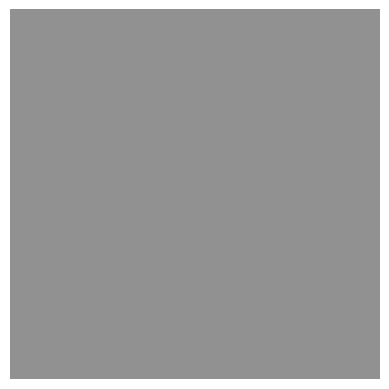

In [34]:
# volume_tester.py

import tritonclient.grpc as grpcclient
import numpy as np
import time

# Configuration
model_name = "animev3"
server_url = "localhost:8001"

# Create a Triton client
try:
    triton_client = grpcclient.InferenceServerClient(url=server_url)
except Exception as e:
    print(f"channel creation failed: {str(e)}")
    sys.exit(1)

# Define the prompt
prompt = "sailing ship in storm ultra realism 4k"
negative_prompt = ""

# Create input tensors
inputs = []
inputs.append(grpcclient.InferInput("prompt", [1, 1], "BYTES"))
inputs.append(grpcclient.InferInput("negative_prompt", [1, 1], "BYTES"))


# Set input data
inputs[0].set_data_from_numpy(np.array([[prompt]], dtype=np.object_))
inputs[1].set_data_from_numpy(np.array([[negative_prompt]], dtype=np.object_))

# Create output tensor
outputs = []
outputs.append(grpcclient.InferRequestedOutput("generated_image"))

# Send request to Triton server
start_time = time.time()
results = triton_client.infer(model_name=model_name, inputs=inputs, outputs=outputs)
end_time = time.time()

# Calculate and print the time taken for inference
print(f"Inference time: {end_time - start_time} seconds")

# Get the output data
generated_image = results.as_numpy("generated_image")

# Display the generated image
import matplotlib.pyplot as plt

plt.imshow(generated_image[0])
plt.axis('off')
plt.show()
